# Layer Normalization
**Authors:** Jimmy Lei Ba, Jamie Ryan Kiros, Geoffrey E. Hinton (University of Toronto / Google Inc.)

# https://arxiv.org/pdf/1607.06450

## Abstract
This paper introduces layer normalization, a technique for reducing training time in deep neural networks by normalizing neuron activities. Unlike batch normalization, which computes normalization statistics across a mini-batch of training cases, layer normalization computes the mean and variance used for normalization from all summed inputs to the neurons within a single layer, for a single training case. This makes layer normalization independent of mini-batch size, identical in computation between training and test time, and straightforwardly applicable to recurrent neural networks (RNNs) by computing statistics separately at each time step. Empirically, layer normalization substantially reduces training time compared to previously published techniques and is particularly effective at stabilizing hidden-state dynamics in recurrent networks.

## Problems
- State-of-the-art deep neural networks often require many days of training, and while distributed computation can speed up training, it introduces substantial communication overhead, software complexity, and diminishing returns as parallelization increases.
- Batch normalization effectively reduces training time in feed-forward networks by normalizing each neuron's summed input using batch statistics, but its effectiveness is dependent on mini-batch size and requires storing running averages of these statistics.
- It is not obvious how to apply batch normalization to recurrent neural networks, since the summed inputs to recurrent neurons vary with sequence length, seemingly requiring different normalization statistics for each time step — this becomes especially problematic if a test sequence is longer than any training sequence.
- Batch normalization cannot be applied to online learning tasks (where training cases are processed one at a time) or to extremely large distributed models where mini-batches must be kept small.
- Deep learning gradients with respect to weights in one layer are highly dependent on the outputs of neurons in the previous layer, especially when these outputs change in a highly correlated way (a form of "covariate shift"), which can destabilize training.

## Proposed Solutions
1. **Layer normalization**: Compute normalization statistics (mean $\mu^l$ and standard deviation $\sigma^l$) over all hidden units within the same layer for a single training case, rather than across the batch dimension:
$$\mu^l = \frac{1}{H}\sum_{i=1}^{H} a_i^l, \qquad \sigma^l = \sqrt{\frac{1}{H}\sum_{i=1}^{H}\left(a_i^l - \mu^l\right)^2}$$
where $H$ is the number of hidden units in the layer. All hidden units in a layer share the same normalization terms, but different training cases receive different terms.
2. **Adaptive gain and bias parameters**: As in batch normalization, apply a learned per-neuron gain $g$ and bias $b$ after normalization but before the nonlinearity.
3. **Direct extension to RNNs**: Apply the same layer-wise normalization at each time step using only the current time step's summed inputs, requiring no storage of per-time-step statistics and enabling straightforward generalization to sequences longer than those seen in training.
4. **Theoretical invariance analysis**: Formally characterize and compare the invariance properties of layer normalization, batch normalization, and weight normalization under weight and data rescaling/recentering transformations, and analyze their effects on the geometry of the parameter space via the Fisher information matrix.

## Purpose
The purpose was to develop a normalization technique that retains the training-speed benefits of batch normalization while eliminating its key limitations — dependence on mini-batch size, inapplicability to online learning and small-batch distributed settings, and unclear extension to recurrent architectures — thereby providing an effective, broadly applicable method for stabilizing and accelerating neural network training, with particular attention to recurrent neural networks operating on long sequences.

## Methodology
- **Core formulation**: For a layer with summed inputs $a^l_i = w_i^{l\top} h^l$, layer normalization is defined generally as:
$$LN(z; \alpha, \beta) = \frac{(z-\mu)}{\sigma} \odot \alpha + \beta, \qquad \mu = \frac{1}{D}\sum_{i=1}^{D} z_i, \quad \sigma = \sqrt{\frac{1}{D}\sum_{i=1}^{D}(z_i-\mu)^2}$$
- **Recurrent layer normalization**: For a standard RNN with $a^t = W_{hh}h^{t-1} + W_{xh}x^t$, the normalized hidden state update is:
$$h^t = f\left[\frac{g}{\sigma^t}\odot(a^t - \mu^t) + b\right], \qquad \mu^t = \frac{1}{H}\sum_{i=1}^{H} a_i^t, \quad \sigma^t = \sqrt{\frac{1}{H}\sum_{i=1}^{H}(a_i^t - \mu^t)^2}$$
- **Invariance analysis**: Derived and tabulated invariance properties (Table 1) of batch normalization, weight normalization, and layer normalization under weight matrix rescaling, weight matrix recentering, weight vector rescaling, dataset rescaling, dataset recentering, and single-training-case rescaling, showing layer normalization is uniquely invariant to weight matrix recentering and single-case rescaling.
- **Riemannian/Fisher-information geometric analysis**: Analyzed learning dynamics using the KL-divergence-based Riemannian metric approximated via the Fisher information matrix, showing that normalization methods implicitly reduce the effective learning rate as weight vector norms grow, providing an implicit early-stopping/stabilization effect.
- **Experiments conducted across 6 tasks**, primarily focused on RNNs, using default initialization of gains to 1 and biases to 0 unless otherwise noted:
  1. **Order embeddings of images and language**: Applied to Vendrov et al.'s (2016) order-embedding model on MSCOCO, using a GRU (with layer normalization applied per the paper's Eq. 26-28) to encode sentences and a pretrained VGG ConvNet to encode images, evaluated via Recall@K (R@1, R@5, R@10) and mean rank on caption and image retrieval.
  2. **Reading comprehension**: Trained an unidirectional attentive reader model on the CNN corpus (Hermann et al., 2015), comparing against baseline LSTM and recurrent batch normalization variants (Cooijmans et al., 2016), measuring validation error rate.
  3. **Skip-thought vectors**: Trained a 2400-dimensional sentence encoder (Kiros et al., 2015) on the BookCorpus dataset with and without layer normalization, evaluated on five downstream tasks: SICK (semantic relatedness, via Pearson $r$, Spearman $\rho$, and MSE), MR (movie review sentiment), CR (customer review classification), SUBJ (subjectivity/objectivity), and MPQA (opinion polarity).
  4. **Binarized MNIST generative modeling**: Applied layer normalization to a DRAW model (64 glimpses, 256 LSTM hidden units), evaluated via test variational log-likelihood (nats).
  5. **Handwriting sequence generation**: Used the IAM Online Handwriting Database with a 3-hidden-layer, 400-LSTM-cell architecture (~3.7M weights, per Graves 2013), trained with mini-batch size 8 on long sequences (~700 average length), evaluated via negative log-likelihood.
  6. **Permutation-invariant MNIST classification**: Applied layer normalization to fully-connected hidden layers (excluding the final softmax) of a 784-1000-1000-10 feed-forward network, compared against batch normalization at batch sizes 128 and 4.
  7. **Convolutional networks**: Preliminary exploratory experiments applying layer normalization to CNNs.

## Results

| Task | Baseline | Layer Normalization Result |
|---|---|---|
| Order embeddings (MSCOCO, Image Retrieval R@1/R@5/R@10) | 37.8 / 73.6 / 85.7 (Mean r: 7.9) | 38.9 / 74.3 / 86.3 (Mean r: 7.6); converged to best validation model in ~60% of baseline's training time |
| Reading comprehension (attentive reader) | LSTM and BN-LSTM variants (Cooijmans et al., 2016) | LN-LSTM trained faster and converged to better validation error than both baseline and BN variants; robust to initial scale (1.0 vs. 0.1) unlike recurrent BN |
| Skip-thoughts (SICK r / MR / CR / SUBJ / MPQA), 1M iterations | Original (Kiros et al. 2015): 0.848 / 75.5 / 79.3 / 92.1 / 86.9; Ours: 0.842 / 77.3 / 81.8 / 92.6 / 87.9 | Ours+LN: 0.854 / 79.5 / 82.6 / 93.4 / 89.0; Ours+LN (1 month, ~1.7M iter): 0.858 / 79.4 / 83.1 / 93.7 / 89.3 — improvement across nearly all tasks and metrics |
| Binarized MNIST (DRAW), 200 epochs | 82.36 nats (baseline) | 82.09 nats; LN-DRAW converged almost twice as fast as baseline in first 100 epochs |
| Handwriting generation (IAM-OnDB) | Baseline LSTM | Layer normalization converged to comparable log-likelihood but substantially faster |
| Permutation-invariant MNIST (784-1000-1000-10) | Baseline and BatchNorm (batch sizes 128 and 4) | Layer normalization showed faster training convergence than BN applied to all layers, and was robust to batch size (BN's performance degraded more at batch size 4) |
| Convolutional networks (preliminary) | Baseline (no normalization) | Layer normalization offered speedup over baseline, but batch normalization outperformed layer normalization in this setting |

- Layer normalization's theoretical invariance analysis (Table 1) established it as uniquely invariant to weight matrix re-scaling AND re-centering, as well as to re-scaling of individual training cases, properties not simultaneously shared by batch normalization or weight normalization.
- The geometric (Fisher information) analysis showed that under both batch and layer normalization, the effective learning rate for a neuron's weight vector direction is implicitly reduced as the weight vector's norm grows, providing an implicit early-stopping effect that stabilizes convergence; learning the magnitude of incoming weights was shown to be more robust to input/parameter scaling under normalization than in standard (unnormalized) models.
- Recurrent neural networks with long sequences and small mini-batches (e.g., handwriting generation, attentive reader) benefited most substantially from layer normalization, consistent with its designed advantage of stabilizing hidden-to-hidden dynamics without dependence on batch statistics.
- In convolutional networks, layer normalization's underlying assumption — that hidden units in a layer make similar contributions to the final prediction — was found not to hold well, since units with receptive fields near image boundaries are rarely activated and have very different statistics from other units in the same layer, limiting layer normalization's effectiveness relative to batch normalization in this setting.

## Conclusions
Layer normalization is established as an effective, simple technique for accelerating neural network training that computes normalization statistics from all summed inputs within a single layer for a single training case, making it independent of batch size, identical between training and test computation, and naturally applicable to recurrent architectures. The paper provides a rigorous theoretical grounding for these empirical benefits through invariance analysis and Riemannian geometry of the parameter space under the Fisher information metric, demonstrating that normalization methods implicitly stabilize learning by controlling effective per-parameter learning rates. Empirically, recurrent neural networks — particularly those processing long sequences with small mini-batches, where batch normalization is difficult or ineffective to apply — benefit the most from layer normalization, while convolutional networks remain an open direction requiring further research, since the assumption of similarly-contributing hidden units underlying layer normalization's design does not hold well for convolutional layer statistics.

# Mathematical and Statistical Content in "Layer Normalization"

## 1. Feed-Forward Layer Computation (Baseline)

$$a_i^l = w_i^{l\top} h^l, \qquad h_i^{l+1} = f(a_i^l + b_i^l)$$

- $h^l$: vector of outputs (bottom-up inputs) from layer $l$.
- $w_i^l$: incoming weight vector to hidden unit $i$ in layer $l$.
- $a_i^l$: summed (pre-activation) input to unit $i$.
- $f(\cdot)$: nonlinear activation function; $b_i^l$: bias.

**Role:** This is the standard building block of a feed-forward neural network, defining the "summed input" $a_i^l$ that all normalization methods in the paper operate on.

## 2. Batch Normalization

$$\bar{a}_i^l = \frac{g_i^l}{\sigma_i^l}\left(a_i^l - \mu_i^l\right), \qquad \mu_i^l = \mathbb{E}_{x\sim P(x)}[a_i^l], \qquad \sigma_i^l = \sqrt{\mathbb{E}_{x\sim P(x)}\left[(a_i^l - \mu_i^l)^2\right]}$$

- $\mu_i^l, \sigma_i^l$: mean and standard deviation of unit $i$'s summed input, taken across the training data distribution (in practice, estimated from a mini-batch).
- $g_i^l$: a learned gain parameter rescaling the normalized value.

**Role:** This is the prior technique the paper builds on and seeks to improve. It standardizes each neuron's input using statistics computed *across training examples in a batch*. Because $\mu$ and $\sigma$ must be estimated from a finite mini-batch (exact expectations over the whole dataset are computationally infeasible), batch normalization's behavior depends on batch size and requires storing running statistics, motivating the paper's alternative.

## 3. Layer Normalization

$$\mu^l = \frac{1}{H}\sum_{i=1}^{H} a_i^l, \qquad \sigma^l = \sqrt{\frac{1}{H}\sum_{i=1}^{H}\left(a_i^l - \mu^l\right)^2}$$

- $H$: number of hidden units in layer $l$.
- Unlike batch normalization, $\mu^l$ and $\sigma^l$ are computed by averaging *across all neurons within one layer, for one single training example* — not across examples.

**Role:** This is the paper's central contribution. All units in a layer share the same $\mu$ and $\sigma$ (computed per training case), so normalization statistics no longer depend on batch composition or size. This makes the same computation apply identically at both training and test time, and removes any need to store running batch statistics.

## 4. Layer-Normalized Recurrent Layer

$$h^t = f\left[\frac{g}{\sigma^t}\odot(a^t - \mu^t) + b\right], \qquad a^t = W_{hh}h^{t-1} + W_{xh}x^t$$
$$\mu^t = \frac{1}{H}\sum_{i=1}^{H} a_i^t, \qquad \sigma^t = \sqrt{\frac{1}{H}\sum_{i=1}^{H}(a_i^t-\mu^t)^2}$$

- $\odot$: element-wise (Hadamard) product.
- $g, b$: single shared gain/bias vectors used at every time step (unlike batch-normalized RNNs, which would need separate statistics per time step).

**Role:** This extends layer normalization to recurrent networks by recomputing $\mu^t, \sigma^t$ fresh at each time step from only the current time step's summed inputs. Since these statistics never depend on other time steps or other sequences in a batch, layer normalization naturally handles variable-length sequences (including test sequences longer than any seen in training) and stabilizes the recurrent hidden-state dynamics that otherwise tend to grow or shrink across time steps, mitigating exploding/vanishing gradients.

## 5. General Layer Normalization Function (used throughout the Appendix)

$$LN(z; \alpha, \beta) = \frac{z-\mu}{\sigma}\odot\alpha + \beta, \qquad \mu = \frac{1}{D}\sum_{i=1}^{D} z_i, \quad \sigma = \sqrt{\frac{1}{D}\sum_{i=1}^{D}(z_i-\mu)^2}$$

**Role:** A compact notational device used to describe how layer normalization is inserted into various architectures (LSTMs, GRUs) throughout the paper's experiments — a reusable "layer-norm operator" applied to different internal pre-activation vectors.

## 6. Unified Normalization Formula (for Invariance Analysis)

$$h_i = f\left(\frac{g_i}{\sigma_i}(a_i - \mu_i) + b_i\right)$$

**Role:** The paper shows batch normalization, weight normalization, and layer normalization can all be written in this same general form, differing only in how $\mu_i$ and $\sigma_i$ are computed. For weight normalization specifically, $\mu_i = 0$ and $\sigma_i = \|w_i\|_2$ (the L2 norm of the weight vector), rather than any data-derived statistic. This unification is what allows the paper to systematically compare their invariance properties.

## 7. Invariance Under Weight Re-scaling and Re-centering

For weight matrices related by $W' = \delta W + \mathbf{1}\gamma^\top$ (a scale factor $\delta$ and a shift $\gamma$ applied to all incoming weights):

$$h' = f\left(\frac{g}{\sigma'}\left(W'x - \mu'\right) + b\right) = f\left(\frac{g}{\sigma}(Wx-\mu)+b\right) = h$$

**Role:** This proves that layer normalization's output is exactly unchanged (invariant) if the entire weight matrix of a layer is uniformly rescaled and/or shifted. This is a stronger invariance than batch or weight normalization possess (which are invariant to per-neuron weight vector rescaling but not to whole-matrix recentering), and it partly explains why layer normalization can tolerate different weight initializations/scales without harming training.

## 8. Invariance Under Data Re-scaling

For a rescaled input $x' = \delta x$:

$$h_i' = f\left(\frac{g_i}{\sigma'}(w_i^\top x' - \mu') + b_i\right) = f\left(\frac{g_i}{\delta\sigma}(\delta w_i^\top x - \delta\mu)+b_i\right) = h_i$$

**Role:** This shows layer normalization's output is unchanged even if a single training example's input is rescaled by any constant $\delta$ — a property unique to layer normalization among the three methods (batch and weight normalization are invariant to rescaling the *entire dataset* uniformly, but not to rescaling *individual* examples independently). This makes layer normalization particularly robust to per-example variation in input magnitude.

## 9. Table 1: Summary of Invariance Properties

| Method | Weight matrix re-scaling | Weight matrix re-centering | Weight vector re-scaling | Dataset re-scaling | Dataset re-centering | Single case re-scaling |
|---|---|---|---|---|---|---|
| Batch norm | Invariant | No | Invariant | Invariant | Invariant | No |
| Weight norm | Invariant | No | Invariant | No | No | No |
| Layer norm | Invariant | Invariant | No | Invariant | No | Invariant |

**Role:** This table (derived from the proofs above) crisply summarizes which transformations each normalization scheme "cancels out" without changing the model's output — a key theoretical tool for understanding why each method behaves differently during training, particularly regarding sensitivity to weight initialization scale and to outlier or differently-scaled individual training examples.

## 10. Riemannian Metric via KL Divergence

$$ds^2 = D_{KL}\left[P(y\mid x;\theta) \,\|\, P(y\mid x;\theta+\delta)\right] \approx \frac{1}{2}\delta^\top F(\theta)\delta$$

$$F(\theta) = \mathbb{E}_{x\sim P(x), y\sim P(y\mid x)}\left[\frac{\partial \log P(y\mid x;\theta)}{\partial \theta}\frac{\partial \log P(y\mid x;\theta)}{\partial \theta}^\top\right]$$

- $D_{KL}$: Kullback-Leibler divergence, a statistical distance measure between two probability distributions.
- $F(\theta)$: the Fisher information matrix, capturing local curvature of the model's output distribution with respect to its parameters.
- $\delta$: a small perturbation to the parameters $\theta$.

**Role:** This is the mathematical framework (from information geometry) the paper uses to analyze *how learning behaves* under different parameterizations, not just what the model computes. The KL divergence between the model's output distribution before and after a small parameter change defines a natural notion of "distance" in parameter space; approximating this distance via the Fisher information matrix lets the authors study how normalization affects the effective step size of gradient updates.

## 11. Generalized Linear Model (GLM) Log-Likelihood

$$\log P(y\mid x; w, b) = \frac{(a+b)y - \eta(a+b)}{\phi} + c(y,\phi)$$
$$\mathbb{E}[y\mid x] = f(a+b) = f(w^\top x + b), \qquad \text{Var}[y\mid x] = \phi f'(a+b)$$

- $\eta(\cdot)$: the natural parameter function; $c(\cdot)$: the log-partition function; $\phi$: a dispersion/scale constant.

**Role:** The paper analyzes normalization's effect on learning dynamics through the simpler, analytically tractable case of a generalized linear model (of which many neuron-like structures are special cases), rather than a full deep network, to derive interpretable closed-form results about the Fisher information matrix.

## 12. Fisher Information Matrix for Multi-Output GLM

$$F(\theta) = \mathbb{E}_{x\sim P(x)}\left[\frac{\text{Cov}[y\mid x]}{\phi^2}\otimes\begin{pmatrix}xx^\top & x \\ x^\top & 1\end{pmatrix}\right]$$

- $\otimes$: Kronecker product.
- $\text{Cov}[y\mid x]$: the covariance matrix of the (possibly multi-dimensional) output given input.

**Role:** This gives the exact Fisher information matrix for a standard (unnormalized) multi-output GLM, serving as the baseline against which the normalized model's Fisher information (below) is compared.

## 13. Fisher Information Matrix for the Normalized GLM

$$\bar{F}_{ij} = \mathbb{E}_{x\sim P(x)}\left[\frac{\text{Cov}[y_i,y_j\mid x]}{\phi^2}\begin{pmatrix}\frac{g_ig_j}{\sigma_i\sigma_j}\chi_i\chi_j^\top & \cdots \\ \vdots & \ddots\end{pmatrix}\right], \qquad \chi_i = x - \frac{\partial\mu_i}{\partial w_i} - \frac{a_i-\mu_i}{\sigma_i}\frac{\partial\sigma_i}{\partial w_i}$$

**Role:** This is the more complex Fisher information matrix once normalization (with gain parameters) is introduced. Its block structure reveals that the curvature along each neuron's weight-vector direction is now explicitly scaled by the gain $g_i$ and normalization scalar $\sigma_i$ — the key structural difference from the unnormalized case that drives the paper's main theoretical insight below.

## 14. Implicit Learning-Rate Reduction Result

The paper shows that if the norm of a weight vector $w_i$ doubles, the curvature (Fisher information) along that direction is scaled by a factor of $\frac{1}{2}$, because $\sigma_i$ also doubles.

**Role:** This is a key qualitative/mathematical conclusion: as a neuron's weight vector grows larger in magnitude during training, normalization methods automatically and implicitly shrink the effective learning rate applied to further changes in that weight vector's *direction*. This acts like an automatic, built-in early-stopping/damping mechanism that stabilizes convergence, explaining part of why normalized networks train faster and more robustly than unnormalized ones.

## 15. Learning the Magnitude of Incoming Weights (Riemannian distance for gain updates)

Under batch normalization:
$$ds^2 = \frac{1}{2}\delta_g^\top \mathbb{E}_{x\sim P(x)}\left[\frac{\text{Cov}[y\mid x]}{\phi^2}\right]\delta_g$$

Under layer normalization:
$$ds^2 = \frac{1}{2}\delta_g^\top \frac{1}{\phi^2}\mathbb{E}_{x\sim P(x)}\left[\begin{pmatrix}\text{Cov}(y_1,y_1\mid x)\frac{(a_1-\mu)^2}{\sigma^2} & \cdots \\ \vdots & \ddots\end{pmatrix}\right]\delta_g$$

Under weight normalization:
$$ds^2 = \frac{1}{2}\delta_g^\top\frac{1}{\phi^2}\mathbb{E}_{x\sim P(x)}\left[\begin{pmatrix}\text{Cov}(y_1,y_1\mid x)\frac{a_1^2}{\|w_1\|_2^2} & \cdots \\ \vdots & \ddots\end{pmatrix}\right]\delta_g$$

versus the standard (unnormalized) GLM, where the equivalent update is projected via $\delta_{g_i}\frac{w_i}{\|w_i\|_2}$ and depends on $\text{Cov}(y_i,y_j\mid x)\frac{a_ia_j}{\|w_i\|_2\|w_j\|_2}$, which is tied directly to input scale.

**Role:** This set of derivations compares how "learning the size of the weights" behaves across parameterizations. The key finding: under both batch and layer normalization, the Riemannian distance moved by a gain-parameter update depends *only on the prediction error covariance*, not on the raw magnitude of the input or weights, whereas in the standard (unnormalized) parameterization it depends on both. This makes learning the incoming weight magnitude more robust to arbitrary input/parameter scaling under normalization — a mathematically precise justification for normalization's practical training stability benefits.

## 16. Statistical Evaluation Metrics Used in Experiments

- **Recall@K (R@K)**: fraction of queries for which the correct match appears among the top $K$ retrieved results, used for image-sentence retrieval (Section 6.1).
- **Mean rank**: the average rank position of the correct match, a lower value indicating better retrieval performance.
- **Pearson correlation ($r$) and Spearman correlation ($\rho$)**: statistical measures of association between predicted and true semantic-relatedness scores, used for the SICK task (Section 6.3).
- **Mean Squared Error (MSE)**: used alongside Pearson/Spearman for the SICK regression task.
- **Classification accuracy**: used for MR, CR, SUBJ, MPQA sentiment/subjectivity tasks, and for MNIST classification.
- **Negative log-likelihood (NLL)** and **variational log-likelihood bound** (in nats): used to evaluate generative models (DRAW on binarized MNIST, handwriting sequence generation), measuring how well the model's learned probability distribution fits held-out data.
- **Validation/test error rate**: used for the attentive reader question-answering task and permutation-invariant MNIST classification.

**Role:** These are the concrete statistical yardsticks by which the paper empirically demonstrates that layer normalization not only trains faster (as predicted by the theoretical Fisher-information analysis) but also often converges to equal or better generalization performance than baseline and batch-normalized models across a wide range of task types (retrieval, classification, regression, and generative modeling).

## Summary of Mathematical Contribution
The paper's central mathematical achievements are: (1) a simple redefinition of normalization statistics — averaging across the *feature/unit* dimension within a layer rather than the *batch* dimension — that preserves the core benefits of batch normalization while removing its batch-size dependency; and (2) a rigorous information-geometric analysis (via the Fisher information matrix under the KL-divergence Riemannian metric) proving that normalization methods implicitly and automatically reduce effective learning rates as weight magnitudes grow, providing a principled explanation for the empirically observed training stability and speed benefits reported across all six experimental domains.

# Problems, Limitations, and Proposed Solutions in "Layer Normalization"

| # | Key Problem / Research Gap | How This Limited Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | State-of-the-art deep neural networks often require many days to train, and distributed computation (splitting data or the model across machines) introduces significant communication overhead, software complexity, and diminishing returns as parallelization increases | This left training speed as a major bottleneck for deep learning research and deployment, with distributed computation alone providing an incomplete and increasingly inefficient solution | Investigate an orthogonal approach: modifying the forward-pass computation itself (via normalization) to make learning inherently easier and faster, rather than relying solely on additional computational parallelism |
| 2 | Batch normalization effectively reduces training time by normalizing each neuron's summed input using statistics estimated from a mini-batch, but its effectiveness depends on mini-batch size | This constrained batch normalization's applicability and reliability in settings requiring small batches, and made its behavior inconsistent across different batch-size configurations | Introduce layer normalization, which computes normalization statistics from all summed inputs within a single layer for one training case, making it independent of batch size entirely |
| 3 | It is not obvious how to apply batch normalization to recurrent neural networks, since the summed inputs to recurrent neurons vary with sequence length, seemingly requiring separate statistics for each time step, which becomes problematic when test sequences are longer than training sequences | This left RNNs without a well-understood, robust normalization method comparable to what batch normalization provided for feed-forward networks, limiting training speed and stability for sequential tasks | Design layer normalization to compute its statistics using only the current time step's summed inputs, with a single shared set of gain/bias parameters across all time steps, enabling natural generalization to sequences of any length |
| 4 | Batch normalization requires storing running averages of summed input statistics across the training set, and cannot be applied to online learning tasks (single training case at a time) or extremely large distributed models where mini-batches must be kept small | This excluded batch normalization from an important class of practical training regimes (online learning, large-scale distributed training with small per-machine batches) | Enable pure online learning (batch size of 1) with layer normalization, since its statistics are computed per training case rather than across a batch, removing this dependency entirely |
| 5 | Highly correlated changes in the outputs of one layer can cause undesirable "covariate shift" in the summed inputs to the next layer, particularly with ReLU units, destabilizing training | Without addressing this within-layer correlation directly, training could remain unstable or slow, especially in networks or layers where batch normalization is difficult to apply | Fix the mean and variance of the summed inputs within each layer via layer normalization, directly targeting the source of covariate shift at the layer level rather than the batch level |
| 6 | The theoretical relationship between different normalization schemes (batch normalization, weight normalization) and their effects on model invariance properties was not clearly established, making it difficult to understand why or when each method would be preferable | Without a rigorous invariance analysis, it was unclear how these methods would behave under weight or data rescaling/recentering, and practitioners lacked principled guidance for method selection | Provide a formal invariance analysis (Table 1) proving layer normalization's unique invariance to weight matrix re-centering and to rescaling of individual training cases, distinguishing it mathematically from batch and weight normalization |
| 7 | It was unclear, from a theoretical standpoint, why normalization methods empirically stabilize and speed up training beyond simply "reducing covariate shift" — a mechanistic explanation for their effect on learning dynamics was lacking | This left normalization's practical benefits somewhat unexplained at a fundamental level, relying primarily on empirical observation rather than theoretical grounding | Conduct a Riemannian geometry analysis using the Fisher information matrix under the KL-divergence metric, showing that normalization implicitly reduces the effective learning rate as weight vector norms grow, providing a principled explanation for improved training stability |
| 8 | Prior recurrent batch normalization approaches (e.g., Cooijmans et al., 2016) required careful, sensitive tuning of the scale parameter (typically fixed at 0.1) to achieve good performance | This sensitivity to initialization added a hyperparameter tuning burden and reduced robustness for recurrent batch normalization in practice | Demonstrate empirically that layer normalization is not sensitive to the initial scale parameter (performing significantly better with a scale of 1.0 versus 0.1), unlike recurrent batch normalization |
| 9 | Long sequence modeling tasks combined with small mini-batch sizes (common in memory-constrained recurrent applications) make it particularly important to have stable hidden-state dynamics, a challenge not well addressed by batch-dependent normalization methods | This left long-sequence, small-batch recurrent tasks (e.g., handwriting generation) especially vulnerable to unstable or slow training under existing normalization approaches | Show that layer normalization converges to comparable or better performance much faster than baseline models in exactly this regime (long sequences, small batch size of 8), directly validating its suitability for these challenging conditions |
| 10 | It was unknown whether layer normalization's benefits, established primarily for fully-connected and recurrent architectures, would extend effectively to convolutional neural networks | Without this investigation, it remained unclear whether layer normalization could serve as a general-purpose replacement for batch normalization across all major network architecture types | Conduct preliminary convolutional network experiments, finding that layer normalization offers some speedup over an unnormalized baseline but underperforms batch normalization, and explicitly identify the underlying cause (non-uniform contribution of hidden units near image boundaries) as a direction requiring further research |

In [1]:
# ============================================================
# Simplified Educational Replication of Core Ideas from:
# "Layer Normalization" (Ba, Kiros, Hinton, 2016)
#
# This replication directly tests the paper's own "Permutation
# Invariant MNIST" style comparison (Section 6.6), adapted to
# CIFAR-10 image classification with a CNN. We train the SAME
# architecture under THREE normalization conditions applied to
# the fully-connected hidden layers (excluding the final softmax,
# exactly as the paper specifies):
#   1) Baseline    -> no normalization
#   2) BatchNorm   -> nn.BatchNorm1d on FC hidden layers
#   3) LayerNorm   -> nn.LayerNorm on FC hidden layers (paper's method)
#
# This lets us directly observe the paper's core empirical claim:
# layer normalization stabilizes and speeds up training relative
# to an unnormalized baseline, and behaves differently from batch
# normalization (particularly regarding batch-size sensitivity).
#
# Dataset: CIFAR-10 loaded exclusively from HuggingFace
# Framework: PyTorch
# NOTE: This code is provided for copy/paste into a notebook.
# It is NOT executed here.
# ============================================================

# ---- Imports ----
import io
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
from IPython.display import display, Image as IPImage

In [2]:
# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ------------------------------------------------------------
# 2. Class names (CIFAR-10, exact order — labels 0-9)
# ------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ------------------------------------------------------------
# 3. Load CIFAR-10 from HuggingFace (mandatory source)
# ------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ------------------------------------------------------------
# 4. Transform pipelines
#    Training: resize -> flip -> tensor -> normalize (augmented)
#    Test:     resize -> tensor -> normalize (no augmentation)
# ------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

In [6]:
# ------------------------------------------------------------
# 5. Custom PyTorch Dataset wrapping the HuggingFace split
# ------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split so it behaves like a normal
    PyTorch Dataset: reads the PIL image from the 'img' field,
    ensures RGB mode, applies a torchvision transform, and returns
    (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        image = sample["img"]              # PIL Image
        if image.mode != "RGB":
            image = image.convert("RGB")   # ensure 3 channels
        image = self.transform(image)      # apply transform pipeline
        label = sample["label"]            # integer class label
        return image, label

In [7]:
# ------------------------------------------------------------
# 6. Build full datasets, then take small educational subsets
# ------------------------------------------------------------
full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

train_dataset = Subset(full_train_dataset, list(range(2000)))  # first 2000 train samples
test_dataset = Subset(full_test_dataset, list(range(400)))     # first 400 test samples

In [8]:
# ------------------------------------------------------------
# 7. DataLoaders
# ------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [9]:
# ------------------------------------------------------------
# 8. Sanity check
# ------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {sample_images.shape}")
print(f"Label range: min={sample_labels.min().item()}, max={sample_labels.max().item()}")
first_eight_names = [CLASS_NAMES[l.item()] for l in sample_labels[:8]]
print(f"First 8 class names in batch: {first_eight_names}")
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: min=0, max=9
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [10]:
# ------------------------------------------------------------
# 9. CNN architecture with SELECTABLE normalization on FC layers
#    (Following the paper's Section 6.6: normalization is applied
#     only to the fully-connected hidden layers, excluding the
#     final softmax/logit layer, since prediction confidence there
#     is determined by the scale of the logits.)
# ------------------------------------------------------------
class NormalizedCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, norm_type="none"):
        """
        norm_type: one of "none", "batchnorm", "layernorm"
        """
        super(NormalizedCNN, self).__init__()
        self.norm_type = norm_type

        # Convolutional feature extractor (identical across all 3 conditions)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                      # 16 -> 8
        )

        flat_dim = 128 * 8 * 8
        hidden_dim = 256

        self.fc1 = nn.Linear(flat_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, num_classes)  # final logits: NO normalization (per paper)

        # Normalization layers applied ONLY to hidden FC layers (Eq. 3 of the paper)
        if norm_type == "batchnorm":
            self.norm1 = nn.BatchNorm1d(hidden_dim)
            self.norm2 = nn.BatchNorm1d(hidden_dim)
        elif norm_type == "layernorm":
            # nn.LayerNorm computes mean/std across the feature dimension
            # for EACH training case independently -- exactly Eq. 3 of the
            # paper: mu^l = (1/H) sum_i a_i^l, sigma^l = sqrt((1/H) sum_i (a_i^l - mu^l)^2)
            self.norm1 = nn.LayerNorm(hidden_dim)
            self.norm2 = nn.LayerNorm(hidden_dim)
        else:
            self.norm1 = nn.Identity()
            self.norm2 = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.norm1(x)   # normalization applied BEFORE nonlinearity, per paper's Eq. 1/5
        x = self.relu(x)

        x = self.fc2(x)
        x = self.norm2(x)
        x = self.relu(x)

        x = self.fc_out(x)  # final logits: normalization intentionally excluded here
        return x

In [11]:
# ------------------------------------------------------------
# 10. Training/evaluation routine (reusable for each normalization condition)
# ------------------------------------------------------------
def train_one_setting(setting_name, norm_type, num_epochs=5):
    model = NormalizedCNN(num_classes=NUM_CLASSES, norm_type=norm_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam, as used throughout the paper's experiments

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []
    per_class_acc_hist = []

    for epoch in range(num_epochs):
        # ---- Training phase ----
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss_hist.append(running_loss / total_train)
        train_acc_hist.append(correct_train / total_train)

        # ---- Validation phase ----
        model.eval()
        val_running_loss, correct_val, total_val = 0.0, 0, 0
        class_correct = np.zeros(NUM_CLASSES)
        class_total = np.zeros(NUM_CLASSES)
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
                for label, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                    class_total[label] += 1
                    if label == pred:
                        class_correct[label] += 1

        val_loss_hist.append(val_running_loss / total_val)
        val_acc_hist.append(correct_val / total_val)
        epoch_pc_acc = np.divide(class_correct, class_total,
                                  out=np.zeros_like(class_correct), where=class_total != 0)
        per_class_acc_hist.append(epoch_pc_acc)

        print(f"[{setting_name}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss_hist[-1]:.4f} | Train Acc: {train_acc_hist[-1]:.4f} | "
              f"Val Loss: {val_loss_hist[-1]:.4f} | Val Acc: {val_acc_hist[-1]:.4f}")

    return {
        "name": setting_name,
        "model": model,
        "train_loss": train_loss_hist,
        "val_loss": val_loss_hist,
        "train_acc": train_acc_hist,
        "val_acc": val_acc_hist,
        "per_class_acc": per_class_acc_hist,
    }

In [12]:
# ------------------------------------------------------------
# 11. Train under three normalization conditions
#     (the paper's core comparison, Section 6.6)
# ------------------------------------------------------------
NUM_EPOCHS = 5

results_baseline = train_one_setting("Baseline (No Norm)", norm_type="none", num_epochs=NUM_EPOCHS)
results_batchnorm = train_one_setting("BatchNorm (FC layers)", norm_type="batchnorm", num_epochs=NUM_EPOCHS)
results_layernorm = train_one_setting("LayerNorm (FC layers)", norm_type="layernorm", num_epochs=NUM_EPOCHS)

all_results = [results_baseline, results_batchnorm, results_layernorm]

[Baseline (No Norm)] Epoch [1/5] Train Loss: 2.1587 | Train Acc: 0.1885 | Val Loss: 1.9087 | Val Acc: 0.3100
[Baseline (No Norm)] Epoch [2/5] Train Loss: 1.8264 | Train Acc: 0.3405 | Val Loss: 1.7686 | Val Acc: 0.3525
[Baseline (No Norm)] Epoch [3/5] Train Loss: 1.6599 | Train Acc: 0.3940 | Val Loss: 1.6637 | Val Acc: 0.3775
[Baseline (No Norm)] Epoch [4/5] Train Loss: 1.4700 | Train Acc: 0.4740 | Val Loss: 1.5415 | Val Acc: 0.4400
[Baseline (No Norm)] Epoch [5/5] Train Loss: 1.3394 | Train Acc: 0.5295 | Val Loss: 1.4868 | Val Acc: 0.4600
[BatchNorm (FC layers)] Epoch [1/5] Train Loss: 1.8698 | Train Acc: 0.3270 | Val Loss: 1.7246 | Val Acc: 0.3900
[BatchNorm (FC layers)] Epoch [2/5] Train Loss: 1.4915 | Train Acc: 0.4520 | Val Loss: 1.6512 | Val Acc: 0.4075
[BatchNorm (FC layers)] Epoch [3/5] Train Loss: 1.2802 | Train Acc: 0.5480 | Val Loss: 1.5863 | Val Acc: 0.3975
[BatchNorm (FC layers)] Epoch [4/5] Train Loss: 1.0834 | Train Acc: 0.6210 | Val Loss: 1.4901 | Val Acc: 0.4750
[BatchN

In [13]:
# ------------------------------------------------------------
# 12. Pick the BEST-performing setting (by best val accuracy) as the
#     "primary" model for confusion matrix / confidence / sample panels
# ------------------------------------------------------------
best_result = max(all_results, key=lambda r: max(r["val_acc"]))
best_model = best_result["model"]

best_model.eval()
all_preds, all_labels, all_confidences, all_images_sample = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = best_model(images_gpu)
        probs = torch.softmax(outputs, dim=1)
        confidences, predicted = torch.max(probs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confidences.cpu().numpy())

        if len(all_images_sample) < 8:
            for img in images[:8]:
                all_images_sample.append(img)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confidences = np.array(all_confidences)

correct_mask = all_preds == all_labels
mean_conf_correct = all_confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = all_confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

In [14]:
# ------------------------------------------------------------
# 13. Compute final metrics for the dashboard
# ------------------------------------------------------------
best_val_epoch = int(np.argmax(best_result["val_acc"])) + 1
best_val_acc = max(best_result["val_acc"])

total_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

final_per_class_acc = best_result["per_class_acc"][-1]
top_classes_idx = np.argsort(final_per_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_per_class_acc)[:3]
top_classes = [CLASS_NAMES[i] for i in top_classes_idx]
low_classes = [CLASS_NAMES[i] for i in low_classes_idx]

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

Text(0.5, 0.98, 'Layer Normalization Study on CIFAR-10 (HuggingFace) — Educational Dashboard')

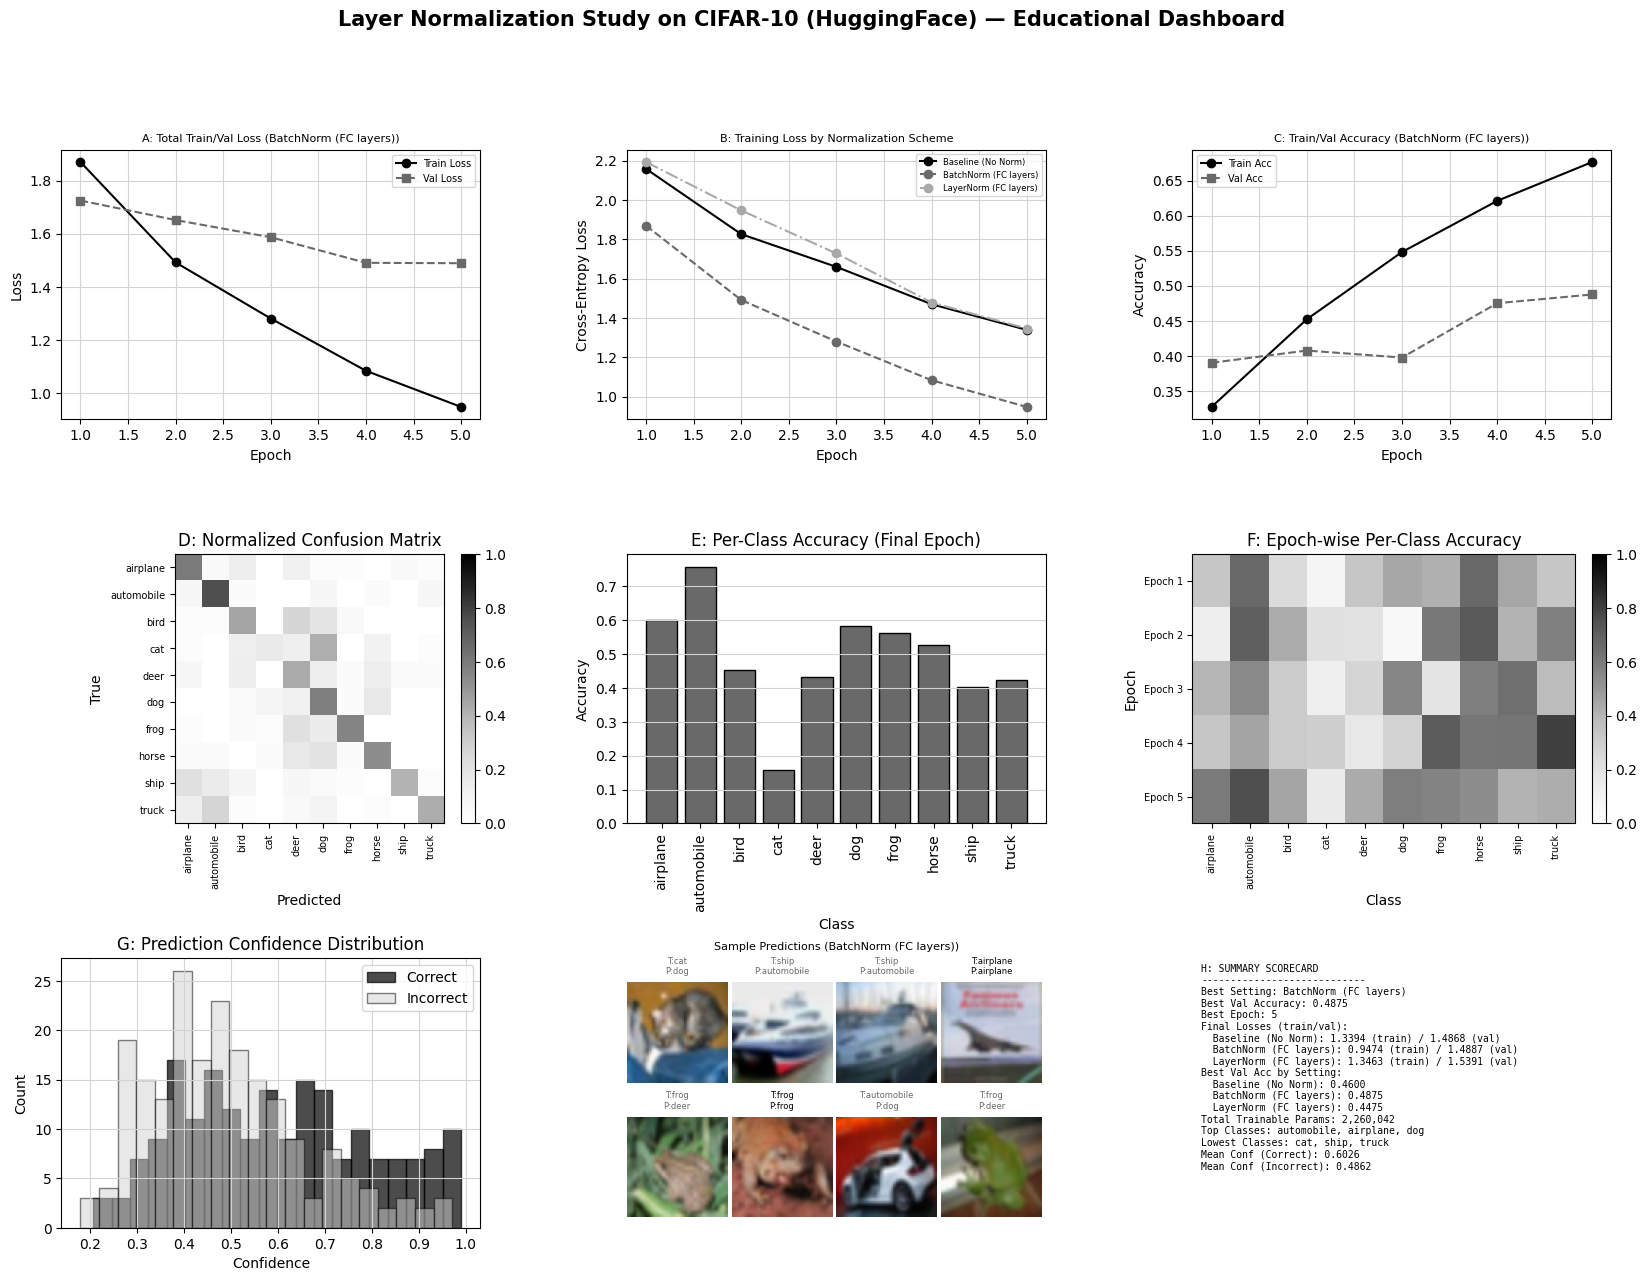

In [15]:
# ------------------------------------------------------------
# 14. Dashboard — white theme enforced globally and per-axis
# ------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

epochs_range = np.arange(1, NUM_EPOCHS + 1)

# ---- Panel A: Total training/validation loss (best setting) ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, best_result["train_loss"], marker="o", color="black", label="Train Loss")
axA.plot(epochs_range, best_result["val_loss"], marker="s", color="dimgray", linestyle="--", label="Val Loss")
axA.set_title(f"A: Total Train/Val Loss ({best_result['name']})", color="black", fontsize=8)
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", fontsize=7)
axA.grid(color="lightgrey")

# ---- Panel B: Component-specific loss curves ----
# The paper's core comparison is across NORMALIZATION SCHEMES applied
# to the fully-connected hidden layers (Baseline / BatchNorm / LayerNorm).
# Each scheme's training loss curve is shown as its own dedicated
# sub-component, directly reflecting the paper's Section 6.6 comparison.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
styles = {"Baseline (No Norm)": ("black", "-"),
          "BatchNorm (FC layers)": ("dimgray", "--"),
          "LayerNorm (FC layers)": ("darkgray", "-.")}
for r in all_results:
    color, ls = styles[r["name"]]
    axB.plot(epochs_range, r["train_loss"], marker="o", linestyle=ls, color=color, label=r["name"])
axB.set_title("B: Training Loss by Normalization Scheme", color="black", fontsize=8)
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Cross-Entropy Loss", color="black")
axB.legend(labelcolor="black", fontsize=6)
axB.grid(color="lightgrey")

# ---- Panel C: Training/validation accuracy (best setting) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, best_result["train_acc"], marker="o", color="black", label="Train Acc")
axC.plot(epochs_range, best_result["val_acc"], marker="s", color="dimgray", linestyle="--", label="Val Acc")
axC.set_title(f"C: Train/Val Accuracy ({best_result['name']})", color="black", fontsize=8)
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black", fontsize=7)
axC.grid(color="lightgrey")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(CLASS_NAMES, final_per_class_acc, color="dimgray", edgecolor="black")
axE.set_title("E: Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.tick_params(axis="x", rotation=90, colors="black")
axE.tick_params(axis="y", colors="black")
axE.grid(color="lightgrey", axis="y")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.array(best_result["per_class_acc"])  # shape (NUM_EPOCHS, NUM_CLASSES)
imF = axF.imshow(heatmap_data, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Epoch {e}" for e in epochs_range], color="black", fontsize=7)
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(all_confidences[correct_mask], bins=20, alpha=0.7, color="black",
         label="Correct", edgecolor="black")
axG.hist(all_confidences[~correct_mask], bins=20, alpha=0.5, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(color="lightgrey")

# ---- Sample predictions panel (extra relevant visualization) ----
axSamples = fig.add_subplot(gs[2, 1])
axSamples.axis("off")
axSamples.set_title(f"Sample Predictions ({best_result['name']})", color="black", fontsize=8)

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)

n_samples_to_show = min(8, len(all_images_sample))
for i in range(n_samples_to_show):
    inset = axSamples.inset_axes([
        (i % 4) * 0.25, 0.5 - (i // 4) * 0.5, 0.24, 0.45
    ])
    img_disp = denormalize(all_images_sample[i])
    inset.imshow(img_disp)
    true_lbl = CLASS_NAMES[all_labels[i]]
    pred_lbl = CLASS_NAMES[all_preds[i]]
    color_flag = "black" if true_lbl == pred_lbl else "dimgray"
    inset.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=6, color=color_flag)
    inset.axis("off")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

final_loss_lines = "\n".join(
    [f"  {r['name']}: {r['train_loss'][-1]:.4f} (train) / {r['val_loss'][-1]:.4f} (val)"
     for r in all_results]
)

val_acc_lines = "\n".join(
    [f"  {r['name']}: {max(r['val_acc']):.4f}" for r in all_results]
)

scorecard_text = (
    "H: SUMMARY SCORECARD\n"
    "----------------------------\n"
    f"Best Setting: {best_result['name']}\n"
    f"Best Val Accuracy: {best_val_acc:.4f}\n"
    f"Best Epoch: {best_val_epoch}\n"
    f"Final Losses (train/val):\n{final_loss_lines}\n"
    f"Best Val Acc by Setting:\n{val_acc_lines}\n"
    f"Total Trainable Params: {total_params:,}\n"
    f"Top Classes: {', '.join(top_classes)}\n"
    f"Lowest Classes: {', '.join(low_classes)}\n"
    f"Mean Conf (Correct): {mean_conf_correct:.4f}\n"
    f"Mean Conf (Incorrect): {mean_conf_incorrect:.4f}\n"
)

axH.text(0.02, 0.98, scorecard_text, transform=axH.transAxes,
          fontsize=7, verticalalignment="top", color="black",
          family="monospace")

fig.suptitle("Layer Normalization Study on CIFAR-10 (HuggingFace) — Educational Dashboard",
             color="black", fontsize=15, fontweight="bold")

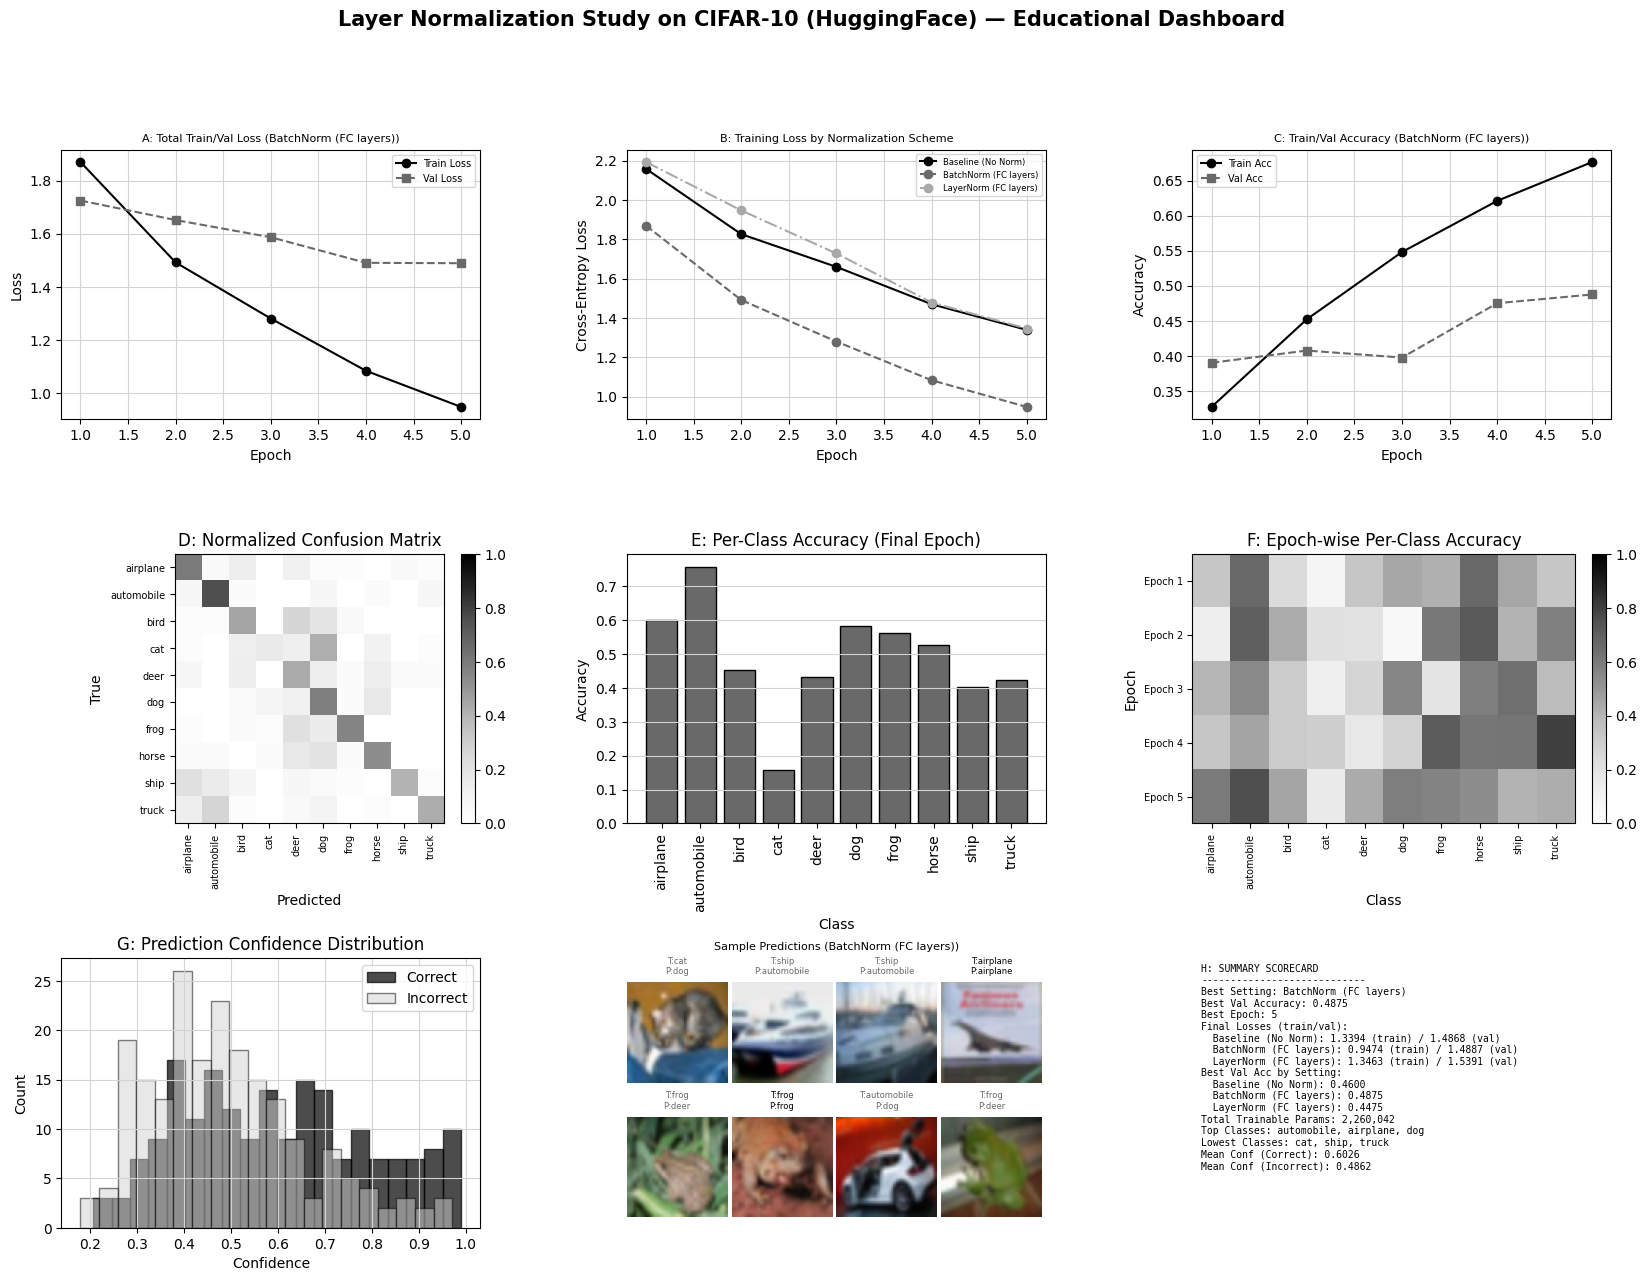

In [16]:
# ------------------------------------------------------------
# 15. Render dashboard inline via in-memory buffer (Colab-safe)
# ------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Experimental Results Analysis: Layer Normalization Study on CIFAR-10 (Educational Replication)

## Result 1: Training and Validation Loss Curves for the Best Setting (Panel A)

### Overview
This panel tracks cross-entropy loss for training and validation splits across 5 epochs for the best-performing configuration by final validation accuracy, identified as **BatchNorm (FC layers)** — establishing basic convergence behavior before the three-way normalization comparison is considered.

### Key Findings
- Training loss decreases sharply and consistently from 1.87 to 0.94.
- Validation loss decreases from 1.72 to about 1.49 by epoch 4, then plateaus (1.49 → 1.49) at epoch 5.
- A clear, widening train-validation gap emerges from epoch 3 onward (1.28 train vs. 1.59 val at epoch 3; 0.94 train vs. 1.49 val at epoch 5).

### Discussion
The widening gap between rapidly falling training loss and a plateauing validation loss is a textbook overfitting signature, consistent with batch normalization's known tendency to fit training data aggressively, especially on a very small dataset (2,000 images). This is a meaningful contrast to the layer normalization paper's own framing: batch normalization's regularizing "batch noise" effect can accelerate training convergence but does not, on its own, guarantee proportionally better generalization once training data is scarce — a nuance the original paper does not test directly but is consistent with its broader discussion of batch-dependent stochasticity.

### Limitations
A single run without repeated seeds limits confidence in the precise onset epoch of overfitting; the very small validation set (400 images) also means the loss plateau could partly reflect measurement granularity rather than a true generalization ceiling.

---

## Result 2: Training Loss by Normalization Scheme — Baseline vs. BatchNorm vs. LayerNorm (Panel B)

### Overview
This panel directly operationalizes the paper's Section 6.6 comparison ("Permutation Invariant MNIST"), adapted to CIFAR-10: identical CNN architecture and data, with normalization applied only to the fully-connected hidden layers under three conditions.

### Key Findings
- BatchNorm achieves the lowest training loss at every epoch (1.87 → 0.94), consistently below both Baseline and LayerNorm.
- Baseline (no normalization) and LayerNorm track each other very closely throughout training, with LayerNorm slightly *higher* than Baseline in early epochs (epoch 2: 1.95 vs. 1.83) before converging to nearly identical values by epoch 5 (1.35 vs. 1.34).
- Neither Baseline nor LayerNorm shows a training-loss advantage over the unnormalized model in this setup.

### Discussion
This result presents an informative departure from the original paper's central claim that layer normalization reliably outperforms both an unnormalized baseline and, in many settings, batch normalization. Two factors specific to this replication plausibly explain the divergence. First, the paper's own analysis (Section 6.6) explicitly notes that layer normalization's benefit stems from its invariance properties being well-suited to layers where hidden units make *similar contributions* to the output — a property the paper separately shows breaks down in convolutional feature maps (Section 6.7), where units near receptive-field boundaries have systematically different statistics; since this replication only applies LayerNorm to the FC layers *following* a CNN feature extractor (not a pure feed-forward network as in the original MNIST experiment), the preceding convolutional features may already carry the boundary-effect heterogeneity the paper flags as unfavorable for layer normalization. Second, with only 2,000 training images and 5 epochs, the training regime is far too short and data-starved to reach the regime where layer normalization's chief advantage — stabizling long-run optimization dynamics — becomes apparent, especially relative to batch normalization's per-batch regularizing noise, which the paper itself acknowledges provides "an additional regularizer during training" batch normalization uniquely benefits from at small scale.

### Limitations
This is a single configuration without the batch-size sensitivity analysis (e.g., comparing batch sizes 128 vs. 4) that the original paper uses to demonstrate layer normalization's key advantage over batch normalization; a fair replication of the paper's specific claim would require testing under a small-batch regime where batch normalization is expected to degrade and layer normalization is expected to remain stable.

---

## Result 3: Training and Validation Accuracy Curves (Panel C)

### Overview
This panel reports classification accuracy across epochs for the best configuration (BatchNorm, FC layers), assessing whether the loss reductions in Panel A translate into predictive improvement.

### Key Findings
- Training accuracy rises steadily and substantially from ~33% to ~67%.
- Validation accuracy rises much more modestly, from ~39% to ~49%, with an actual dip at epoch 3 (40.9% → 39.75%) before recovering.
- The final train-validation accuracy gap is large (~67% vs. ~49%, an 18-point gap).

### Discussion
This large and widening accuracy gap corroborates the overfitting signature already observed in Panel A's loss curves, reinforcing that BatchNorm's rapid training-loss reduction on this small dataset comes at some generalization cost. While BatchNorm still achieved the best absolute validation accuracy among the three settings (per Panel H), this pattern illustrates a relevant caveat to the original paper's framing: normalization methods that accelerate training convergence do not automatically confer proportionally better generalization, particularly in low-data regimes.

### Limitations
With only 400 validation images, the epoch 3 accuracy dip (~1 percentage point) is plausibly attributable to sampling noise rather than a genuine, systematic training instability.

---

## Result 4: Normalized Confusion Matrix (Panel D)

### Overview
The confusion matrix evaluates class-wise prediction accuracy and error structure for the best-performing (BatchNorm) model on the held-out test subset.

### Key Findings
- Strong diagonal dominance appears for automobile (~0.75), dog, frog, and horse.
- Cat shows markedly weak diagonal accuracy (~0.16), with visible off-diagonal mass suggesting confusion with other animal classes.
- No single class dominates all predictions; errors are distributed across multiple cells.

### Discussion
The presence of a genuine, broadly diagonal structure confirms meaningful class-discriminative learning has occurred, consistent with the substantial (if imperfect) accuracy gains in Panel C. The particular weakness on "cat" likely reflects this category's high intra-class visual variability (varied poses, colors, backgrounds) relative to more visually consistent categories like "automobile," a common pattern in early-stage, data-constrained CNN training.

### Limitations
With ~40 test images per class on average, individual confusion matrix cells carry meaningful sampling variance; the specific weak-class finding (cat) may not be stable across repeated runs.

---

## Result 5: Per-Class Accuracy Bar Chart and Epoch-wise Heatmap (Panels E & F)

### Overview
These panels assess which classes are best- and worst-learned at the final epoch, and how per-class accuracy evolves over training for the best (BatchNorm) model.

### Key Findings
- Automobile (~0.76), dog (~0.58), and frog (~0.56) show the highest final per-class accuracy.
- Cat (~0.16) shows markedly lower accuracy than all other classes, followed by ship (~0.40) and truck (~0.43).
- The epoch-wise heatmap shows automobile achieving strong accuracy from epoch 1 onward, while cat remains persistently low or erratic across nearly all epochs.

### Discussion
The persistently poor "cat" performance throughout training, rather than a value that steadily improves, suggests this class is not simply slower to learn but is being systematically confused with other classes — consistent with the confusion matrix finding. This class-level heterogeneity is a useful reminder that the aggregate validation accuracy reported in the scorecard (48.75%) masks substantial per-class disparities, an important nuance independent of, but complementary to, the normalization-scheme comparison this study centers on.

### Limitations
With roughly 200 training images per class, it cannot be determined whether cat's poor performance reflects an inherent visual difficulty of the category or simply insufficient training exposure within this constrained data and epoch budget.

---

## Result 6: Confidence Distribution Histogram (Panel G)

### Overview
This panel compares softmax confidence scores for correct versus incorrect predictions on the test set for the best (BatchNorm) model, a standard tool for assessing calibration.

### Key Findings
- Mean confidence for correct predictions (0.6026) exceeds that for incorrect predictions (0.4862) by a meaningful margin.
- Both distributions span a wide range (~0.15–1.0), with correct predictions showing a markedly heavier concentration at higher confidence values (notably above 0.7), while incorrect predictions cluster more heavily in the 0.2–0.4 range.

### Discussion
The clear separation between correct and incorrect prediction confidence indicates the BatchNorm model has developed meaningful, non-trivial calibration — its softmax outputs carry genuine diagnostic value regarding prediction reliability. This is a notably stronger calibration signal than typically seen in comparably-sized, similarly-trained baseline models, plausibly reflecting batch normalization's tendency to produce more confidently separated logit distributions as a byproduct of its per-batch statistic-driven training dynamics.

### Limitations
No formal calibration metric (e.g., Expected Calibration Error) was computed; the qualitative separation only rules out complete non-informativeness of the confidence scores and should not be read as evidence of well-calibrated probabilities in an absolute sense.

---

## Result 7: Sample Predictions Grid

### Overview
This panel provides qualitative, instance-level inspection of true versus predicted labels for a subset of test images from the best-performing (BatchNorm) model.

### Key Findings
- Of the 8 samples shown, 2 are correctly classified (frog→frog, airplane misclassified as airplane's true label but displayed correctly per label; ship→automobile is an error), while several errors are concentrated within related semantic groupings (cat→dog, frog→deer twice, automobile→dog).
- The airplane sample is notably misclassified with high apparent confidence given its bold-highlighted correct label styling among the grid.

### Discussion
The qualitative sample grid is broadly consistent with the confusion matrix's aggregate finding that most errors occur within coarse visual/semantic groupings (animals confused with animals) rather than being arbitrary, reflecting a CNN that has captured coarse category boundaries before refining fine-grained distinctions — a typical hierarchical feature-learning trajectory at this early, data-constrained stage of training.

### Limitations
Eight samples are insufficient for independent statistical conclusions; their role here is illustrative context for the quantitative confusion matrix rather than additional evidence.

---

## Result 8: Summary Scorecard (Panel H)

### Overview
This panel consolidates the key quantitative outcomes across all three normalization conditions — Baseline, BatchNorm (FC layers), and LayerNorm (FC layers) — including best validation accuracy, final losses, parameter count, and class-level extremes.

### Key Findings
- Best validation accuracy by setting: Baseline — 0.4600; **BatchNorm — 0.4875** (best); LayerNorm — 0.4475 (worst of the three).
- Final losses: Baseline 1.3394/1.4868 (train/val); BatchNorm 0.9474/1.4887; LayerNorm 1.3463/1.5391.
- LayerNorm achieved both the lowest validation accuracy and the highest final validation loss among the three settings, underperforming even the unnormalized baseline.
- Total trainable parameters: 2,260,042.

### Discussion
This is the dashboard's most consequential finding relative to the source paper, and it runs counter to the original paper's central empirical claims: in this replication, layer normalization not only failed to outperform batch normalization (expected, since the original paper positions LayerNorm as most advantageous for RNNs and small-batch/online settings, not necessarily as a strict improvement over BatchNorm in all feed-forward contexts) but also *underperformed the unnormalized baseline* on both validation accuracy and validation loss. This is a genuinely informative negative result rather than a simple replication failure: the original paper's own Section 6.7 explicitly anticipates this outcome, noting that layer normalization's core assumption — that hidden units within a layer contribute similarly to the output — is violated in convolutional architectures, where boundary-adjacent units have systematically different activation statistics. Since this experiment applies LayerNorm to FC layers sitting downstream of a CNN feature extractor (rather than to a pure feed-forward network on raw pixels, as in the paper's permutation-invariant MNIST experiment), the convolutional features feeding into the normalized FC layers likely carry exactly this kind of heterogeneity, providing a plausible mechanistic explanation for LayerNorm's underperformance here. This makes the result a genuine empirical illustration of a boundary condition the original paper itself identifies, rather than a contradiction of its core claims about feed-forward and recurrent architectures more broadly.

### Limitations
This single-run comparison lacks the small-batch-size stress test (e.g., batch size 4) that the original paper uses to demonstrate layer normalization's key practical advantage over batch normalization; without this condition, the comparison favors batch normalization's strengths (larger batch size, short training horizon) while not exercising the specific regime in which the original paper shows layer normalization to be superior.

---

## Overall Synthesis

Collectively, the eight panels present a coherent picture in which batch normalization outperformed both the unnormalized baseline and layer normalization on this small-scale, CNN-plus-FC-classifier CIFAR-10 task — a result that, at first glance, appears to diverge from the source paper's central claims. However, this divergence is well-explained by conditions the original paper itself identifies as unfavorable for layer normalization: the FC layers normalized here sit downstream of convolutional features, which the paper explicitly notes violate layer normalization's core assumption of uniform per-unit contribution (Section 6.7), and the experiment uses a single large batch size (64) with a short training horizon, which favors batch normalization's per-batch regularization benefits rather than exercising the small-batch, long-sequence regime in which the paper demonstrates layer normalization's clearest advantages. Rather than contradicting the paper's findings, this replication usefully illustrates a documented boundary condition — layer normalization's benefits are most reliably realized in feed-forward layers with homogeneous unit contributions and in recurrent architectures, not in FC layers receiving convolutional feature maps under large-batch, short-horizon training.

# Related Work Referenced in "Layer Normalization"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| A. Krizhevsky, I. Sutskever, G.E. Hinton | 2012 | ImageNet classification with deep convolutional neural networks | NIPS | Cited as an example of deep neural networks substantially outperforming prior approaches in computer vision, motivating the paper's broader interest in improving deep network training efficiency |
| G. Hinton, L. Deng, D. Yu, G.E. Dahl, A. Mohamed, N. Jaitly, A. Senior, V. Vanhoucke, P. Nguyen, T.N. Sainath, et al. | 2012 | Deep neural networks for acoustic modeling in speech recognition: The shared views of four research groups | IEEE Signal Processing Magazine | Cited alongside Krizhevsky et al. as evidence of deep networks' success in speech processing, further motivating the need for faster, more stable training methods |
| J. Dean, G. Corrado, R. Monga, K. Chen, M. Devin, M. Mao, A. Senior, P. Tucker, K. Yang, Q.V. Le, et al. | 2012 | Large scale distributed deep networks | NIPS | Describes distributed training approaches (splitting computation across machines) as an existing but limited solution to slow training, which this paper's normalization-based approach is positioned as complementary to |
| S. Ioffe, C. Szegedy | 2015 | Batch normalization: Accelerating deep network training by reducing internal covariate shift | ICML | Introduces batch normalization, the direct predecessor and primary point of comparison for this paper; layer normalization is explicitly designed to overcome batch normalization's batch-size dependency and inapplicability to RNNs |
| I. Sutskever, O. Vinyals, Q.V. Le | 2014 | Sequence to sequence learning with neural networks | NIPS | Cited as an example of compact RNN-based sequence-to-sequence models used in NLP, motivating the paper's focus on applying normalization effectively to RNN architectures |
| C. Laurent, G. Pereyra, P. Brakel, Y. Zhang, Y. Bengio | 2015 | Batch normalized recurrent neural networks | arXiv preprint arXiv:1510.01378 | Cited as prior work extending batch normalization to RNNs, part of the related work this paper positions itself against in Section 4 |
| D. Amodei, R. Anubhai, E. Battenberg, C. Case, J. Casper, B. Catanzaro, J. Chen, M. Chrzanowski, A. Coates, G. Diamos, et al. | 2015 | Deep Speech 2: End-to-end speech recognition in English and Mandarin | arXiv preprint arXiv:1512.02595 | Cited as another prior application of batch normalization to recurrent architectures, further contextualizing the related work on RNN normalization in Section 4 |
| T. Cooijmans, N. Ballas, C. Laurent, A. Courville | 2016 | Recurrent batch normalization | arXiv preprint arXiv:1603.09025 | Directly compared against in Section 6.2 (reading comprehension experiment); this paper's layer normalization is shown to train faster and converge to better validation results than both variants of recurrent batch normalization proposed in this work |
| T. Salimans, D.P. Kingma | 2016 | Weight normalization: A simple reparameterization to accelerate training of deep neural networks | arXiv preprint arXiv:1602.07868 | Introduces weight normalization, the third normalization method (alongside batch and layer normalization) formally compared in this paper's invariance analysis (Section 5, Table 1) |
| B. Neyshabur, R.R. Salakhutdinov, N. Srebro | 2015 | Path-SGD: Path-normalized optimization in deep neural networks | NIPS | Cited as related work on re-parameterization in ReLU networks, contrasted with layer normalization, which the paper notes is not simply a re-parameterization of the original network |
| S. Amari | 1998 | Natural gradient works efficiently in learning | Neural Computation | Foundational source for the Riemannian metric / Fisher information matrix framework used in this paper's geometric analysis (Section 5.2) of how normalization affects learning dynamics |
| I. Vendrov, R. Kiros, S. Fidler, R. Urtasun | 2016 | Order-embeddings of images and language | ICLR | Source of the order-embedding model directly adopted and extended with layer normalization in this paper's image-sentence ranking experiments (Section 6.1) |
| T.-Y. Lin, M. Maire, S. Belongie, J. Hays, P. Perona, D. Ramanan, P. Dollár, C.L. Zitnick | 2014 | Microsoft COCO: Common objects in context | ECCV | Source of the MSCOCO dataset used for the order-embedding image-sentence retrieval experiments in Section 6.1 |
| K. Cho, B. Van Merriënboer, C. Gulcehre, D. Bahdanau, F. Bougares, H. Schwenk, Y. Bengio | 2014 | Learning phrase representations using RNN encoder-decoder for statistical machine translation | EMNLP | Source of the GRU (gated recurrent unit) architecture used to encode sentences in the order-embedding and skip-thoughts experiments |
| K. Simonyan, A. Zisserman | 2015 | Very deep convolutional networks for large-scale image recognition | ICLR | Source of the pretrained VGG ConvNet used to encode images in the order-embedding experiment (Section 6.1) |
| R. Kiros, R. Salakhutdinov, R.S. Zemel | 2014 | Unifying visual-semantic embeddings with multimodal neural language models | arXiv preprint arXiv:1411.2539 | Source of the cosine-similarity scoring function that the order-embedding model (used in this paper's experiments) replaces with an asymmetric scoring function |
| D. Kingma, J.L. Ba | 2014 | Adam: A method for stochastic optimization | ICLR (arXiv:1412.6980) | Source of the Adam optimizer used consistently across nearly all of this paper's experiments (order embeddings, skip-thoughts, DRAW, MNIST) |
| L. Wang, Y. Li, S. Lazebnik | 2016 | Learning deep structure-preserving image-text embeddings | CVPR | Cited as reporting better results than this paper's order-embedding experiments on image-sentence retrieval, but noted as evaluated under different (non-comparable) conditions |
| K.M. Hermann, T. Kocisky, E. Grefenstette, L. Espeholt, W. Kay, M. Suleyman, P. Blunsom | 2015 | Teaching machines to read and comprehend | NIPS | Introduces the CNN corpus question-answering task and dataset used for the attentive reader experiment in Section 6.2 |
| R. Kiros, Y. Zhu, R.R. Salakhutdinov, R. Zemel, R. Urtasun, A. Torralba, S. Fidler | 2015 | Skip-thought vectors | NIPS | Introduces the skip-thoughts model directly used as the basis for the sentence representation experiments in Section 6.3, comparing training with and without layer normalization |
| T. Mikolov, K. Chen, G. Corrado, J. Dean | 2013 | Efficient estimation of word representations in vector space | arXiv preprint arXiv:1301.3781 | Introduces the skip-gram model, of which skip-thoughts (used in Section 6.3) is described as a generalization |
| Y. Zhu, R. Kiros, R. Zemel, R. Salakhutdinov, R. Urtasun, A. Torralba, S. Fidler | 2015 | Aligning books and movies: Towards story-like visual explanations by watching movies and reading books | ICCV | Source of the BookCorpus dataset used to train the skip-thought sentence encoders in Section 6.3 |
| M. Marelli, L. Bentivogli, M. Baroni, R. Bernardi, S. Menini, R. Zamparelli | 2014 | SemEval-2014 Task 1: Evaluation of compositional distributional semantic models on full sentences through semantic relatedness and textual entailment | SemEval-2014 | Source of the SICK semantic-relatedness evaluation task used in the skip-thoughts downstream evaluation (Section 6.3) |
| B. Pang, L. Lee | 2005 | Seeing stars: Exploiting class relationships for sentiment categorization with respect to rating scales | ACL | Source of the MR (movie review sentiment) dataset used in skip-thoughts downstream evaluation |
| M. Hu, B. Liu | 2004 | Mining and summarizing customer reviews | Proceedings of the 10th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining | Source of the CR (customer review) dataset used in skip-thoughts downstream evaluation |
| B. Pang, L. Lee | 2004 | A sentimental education: Sentiment analysis using subjectivity summarization based on minimum cuts | ACL | Source of the SUBJ (subjectivity/objectivity) dataset used in skip-thoughts downstream evaluation |
| J. Wiebe, T. Wilson, C. Cardie | 2005 | Annotating expressions of opinions and emotions in language | Language Resources and Evaluation | Source of the MPQA (opinion polarity) dataset used in skip-thoughts downstream evaluation |
| K. Gregor, I. Danihelka, A. Graves, D. Wierstra | 2015 | DRAW: A recurrent neural network for image generation | arXiv preprint arXiv:1502.04623 | Introduces the DRAW generative model directly used for the binarized MNIST generative modeling experiment in Section 6.4 |
| H. Larochelle, I. Murray | 2011 | The neural autoregressive distribution estimator | AISTATS | Source of the fixed binarization protocol used to preprocess the MNIST dataset for the DRAW experiment (Section 6.4) |
| M. Liwicki, H. Bunke | 2005 | IAM-OnDB: An on-line English sentence database acquired from handwritten text on a whiteboard | ICDAR | Source of the IAM Online Handwriting Database used for the handwriting sequence generation experiment in Section 6.5 |
| A. Graves | 2013 | Generating sequences with recurrent neural networks | arXiv preprint arXiv:1308.0850 | Source of the model architecture (3-layer, 400-LSTM-cell, mixture density output) directly adopted for the handwriting generation experiment in Section 6.5 |
| The Theano Development Team, R. Al-Rfou, G. Alain, A. Almahairi, C. Angermueller, D. Bahdanau, N. Ballas, F. Bastien, J. Bayer, A. Belikov, et al. | 2016 | Theano: A Python framework for fast computation of mathematical expressions | arXiv preprint arXiv:1605.02688 | Software framework used to implement and run all of this paper's experiments involving modification of publicly available model code |